# Week 2: Selective essentiality in TNBC (DepMap)

Compares gene dependency (Chronos scores) between the 25 TNBC cell lines
(from Week 1's `get_tnbc_model_ids`) and every other DepMap cell line with
CRISPR data, gene by gene. Runs **two** statistical tests side by side --
Welch's t-test and Mann-Whitney U -- per the discussion in `NOTES.md`, so
the choice of test can be checked empirically rather than assumed.


**Inputs:** `data/raw/depmap/` (gene effect + model metadata) and `data/raw/tcga/` (expression, for the plausibility check).  
**Outputs:** `data/processed/depmap_tnbc_essentiality.csv` (all genes, both tests), `depmap_tnbc_shortlist.csv` (raw list, superseded) and **`depmap_tnbc_shortlist_v2.csv` (the one used downstream)**.  
**Run order:** after `01_data_eda.ipynb`, before `03_tumor_selectivity_safety.ipynb`.

In [1]:
# Load DepMap + TCGA data via data_utils
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
from scipy import stats

from data_utils import (
    load_model_metadata, load_gene_effect, get_tnbc_model_ids,
    load_tcga_expression, load_tcga_clinical_cdes, get_tnbc_patient_barcodes,
    tcga_patient_barcode, tcga_is_tumor_sample,
)

model = load_model_metadata()
effect = load_gene_effect()
expr = load_tcga_expression()
print("Gene effect matrix:", effect.shape)
print("TCGA expression matrix:", expr.shape)

Gene effect matrix: (1208, 18531)
TCGA expression matrix: (20531, 1212)


## Defining the two comparison groups

TNBC = the 25 cell lines from `get_tnbc_model_ids()` that have CRISPR data
(Week 1). The comparison group is meant to be "every other DepMap cell
line" per the project plan -- but 2 breast cell lines have no
`ModelSubtypeFeatures` value at all (unknown subtype, not confirmed
non-TNBC). Those get excluded from *both* groups, same "unknown isn't
automatically the other bucket" rule applied to DepMap's and TCGA's TNBC
mappings in Week 1 -- we don't actually know whether they're TNBC, so
including them in the "other" group risks quietly diluting it with
possible TNBC lines.


In [2]:
# Split cell lines into the TNBC group and the comparison group, excluding unknown-subtype breast lines from both
tnbc_ids = set(get_tnbc_model_ids(model)) & set(effect.index)

breast = model[model["OncotreeLineage"] == "Breast"]
unknown_subtype_ids = set(breast.index[breast["ModelSubtypeFeatures"].isna()]) & set(effect.index)

other_ids = set(effect.index) - tnbc_ids - unknown_subtype_ids

print(f"TNBC group: {len(tnbc_ids)} cell lines")
print(f"Excluded (unknown subtype): {len(unknown_subtype_ids)} cell lines")
print(f"Comparison ('other') group: {len(other_ids)} cell lines")

tnbc_df = effect.loc[sorted(tnbc_ids)]
other_df = effect.loc[sorted(other_ids)]


TNBC group: 25 cell lines
Excluded (unknown subtype): 2 cell lines
Comparison ('other') group: 1181 cell lines


## Running both tests, gene by gene

For each of the 18,531 genes: drop missing values within each group first
(DepMap's per-gene missingness from Week 1's EDA), require at least 3 valid
values in *both* groups to run a test at all (below that, neither test's
result means much), then run:

- **Welch's t-test** (`equal_var=False` -- doesn't assume the two groups
  have the same variance, which they likely don't given the 25-vs-1,181
  size difference).
- **Mann-Whitney U**, two-sided.

Effect size is the plain mean difference (TNBC mean minus other-group
mean) -- already in Chronos-score units, so a more negative value directly
means "more essential in TNBC than in the rest of DepMap."


In [3]:
# Run both Welch's t-test and Mann-Whitney U per gene, comparing TNBC vs. the comparison group
records = []
for gene in effect.columns:
    a = tnbc_df[gene].dropna().to_numpy()
    b = other_df[gene].dropna().to_numpy()
    if len(a) < 3 or len(b) < 3:
        continue
    effect_size = a.mean() - b.mean()
    _, t_p = stats.ttest_ind(a, b, equal_var=False)
    _, u_p = stats.mannwhitneyu(a, b, alternative="two-sided")
    records.append((gene, effect_size, t_p, u_p, len(a), len(b)))

results = pd.DataFrame(records, columns=["gene", "effect_size", "t_p", "u_p", "n_tnbc", "n_other"])
print(f"Genes tested: {len(results)} of {effect.shape[1]} (rest had <3 valid values in one group)")


Genes tested: 17931 of 18531 (rest had <3 valid values in one group)


## Multiple-testing correction

~18,500 simultaneous tests need correction, and Bonferroni would be far too
conservative for a project whose actual goal is a *shortlist for follow-up*,
not one confirmatory claim -- so Benjamini-Hochberg FDR (q-values) is used
instead, applied separately to each test's p-values.


In [4]:
# Apply Benjamini-Hochberg FDR correction to each test's p-values separately, then save the full results table
results["t_q"] = stats.false_discovery_control(results["t_p"], method="bh")
results["u_q"] = stats.false_discovery_control(results["u_p"], method="bh")

results = results.sort_values("t_q")
results.to_csv("../data/processed/depmap_tnbc_essentiality.csv", index=False)
print(f"Saved {len(results)} rows to data/processed/depmap_tnbc_essentiality.csv")
results.head()


Saved 17931 rows to data/processed/depmap_tnbc_essentiality.csv


,gene,effect_size,t_p,u_p,n_tnbc,n_other,t_q,u_q
13233,RTTN,0.320892,9.326896e-08,4.152423e-07,25,1181,0.001672,0.007446
16813,VCF1,0.130184,1.292815e-05,7.350126e-06,25,1181,0.043475,0.026359
2548,CDKN1A,-0.174677,9.905352e-06,6.073085e-04,25,1181,0.043475,0.151421
3943,DET1,0.194568,1.204142e-05,2.981269e-04,25,1181,0.043475,0.122862
3201,COL5A1,0.108644,1.558827e-05,6.501065e-06,25,1181,0.043475,0.026359


## Comparing the two tests

Before trusting either ranking, check whether they actually agree -- if
Welch's t-test and Mann-Whitney U disagree substantially, that's a sign the
per-gene distributions are non-normal enough that the choice of test
matters a lot, and the more robust one (Mann-Whitney) should be trusted.


In [5]:
# Check how well the two tests agree, both overall (correlation) and at a practical significance threshold
corr = stats.spearmanr(results["t_p"], results["u_p"])
print(f"Spearman correlation between the two tests' p-values: rho={corr.statistic:.4f} (p={corr.pvalue:.2e})")

QVAL_THRESHOLD = 0.10

sig_t = set(results.loc[(results["t_q"] < QVAL_THRESHOLD) & (results["effect_size"] < 0), "gene"])
sig_u = set(results.loc[(results["u_q"] < QVAL_THRESHOLD) & (results["effect_size"] < 0), "gene"])

print(f"\nSignificant + TNBC-selective (q < {QVAL_THRESHOLD}, effect_size < 0):")
print(f"  t-test:        {len(sig_t)} genes")
print(f"  Mann-Whitney:  {len(sig_u)} genes")
print(f"  Overlap:       {len(sig_t & sig_u)} genes ({len(sig_t & sig_u) / len(sig_t | sig_u):.1%} of the union)")


Spearman correlation between the two tests' p-values: rho=0.8727 (p=0.00e+00)

Significant + TNBC-selective (q < 0.1, effect_size < 0):
  t-test:        8 genes
  Mann-Whitney:  13 genes
  Overlap:       6 genes (40.0% of the union)


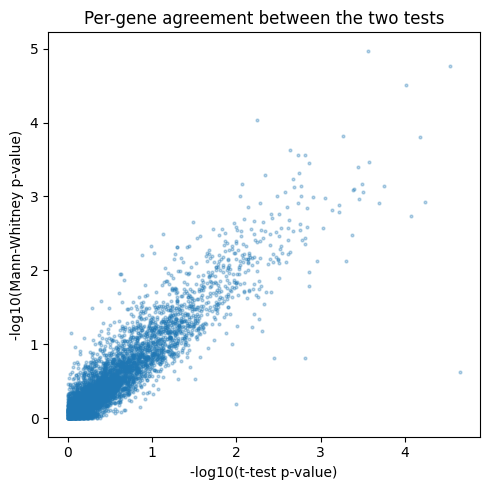

In [6]:
# Scatter the two tests' p-values against each other to visualize that agreement
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5))
sample = results.sample(min(5000, len(results)), random_state=0)
ax.scatter(-np.log10(sample["t_p"]), -np.log10(sample["u_p"]), s=4, alpha=0.3)
lims = [0, max(-np.log10(results["t_p"]).max(), -np.log10(results["u_p"]).max())]
ax.plot(lims, lims, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("-log10(t-test p-value)")
ax.set_ylabel("-log10(Mann-Whitney p-value)")
ax.set_title("Per-gene agreement between the two tests")
plt.tight_layout()
plt.show()


How to read the plot: each dot is one gene, and the dashed line is where the two tests would give identical p-values. Dots hugging the line mean the tests agree on how strong the evidence is. The tests agree well overall (Spearman rho = 0.87) but disagree on which genes clear the q < 0.10 cutoff, so Mann-Whitney was chosen as the primary test for group-size reasons (see `NOTES.md`).

## Shortlist

Sorted by Mann-Whitney's q-value (the more robust test given the group-size
imbalance -- see `NOTES.md`'s test-choice discussion), restricted to genes
where TNBC is *more* essential (`effect_size < 0`). Both tests' q-values are
kept side by side so the choice of test is visible, not hidden.


In [7]:
# Build the raw statistical shortlist: top 40 genes by Mann-Whitney q-value, restricted to the TNBC-selective direction
shortlist = (
    results[results["effect_size"] < 0]
    .sort_values("u_q")
    .head(40)
    .reset_index(drop=True)
)
shortlist.to_csv("../data/processed/depmap_tnbc_shortlist.csv", index=False)
print(f"Shortlist: {len(shortlist)} genes -> data/processed/depmap_tnbc_shortlist.csv")
shortlist


Shortlist: 40 genes -> data/processed/depmap_tnbc_shortlist.csv


,gene,effect_size,t_p,u_p,n_tnbc,n_other,t_q,u_q
0,SMLR1,-0.099091,0.000112,0.000010,25,1181,0.077335,0.027395
1,BROX,-0.097161,0.000272,0.000011,25,1181,0.120132,0.027395
2,OR4K2,-0.087143,0.000029,0.000017,24,1065,0.052531,0.038335
3,GPAT3,-0.072505,0.000098,0.000031,25,1181,0.076191,0.056471
4,TMEM234,-0.090273,0.000196,0.000036,25,1181,0.102337,0.058863
5,POFUT1,-0.101217,0.000074,0.000047,25,1181,0.076191,0.070387
6,MTFR1L,-0.108383,0.000442,0.000052,25,1181,0.139586,0.072295
7,LIX1L,-0.097425,0.000281,0.000071,25,1181,0.120132,0.084970
8,CCDC82,-0.079358,0.000107,0.000087,25,1181,0.076755,0.088842
9,FMC1,-0.072236,0.000416,0.000104,25,1181,0.139586,0.088842


This raw list is kept for the record only. It is contaminated with pan-essential genes and a Y-linked artifact, which the checks below expose, so it is superseded by `depmap_tnbc_shortlist_v2.csv` and is not used downstream.

## Biological plausibility check

Per this project's guardrails, statistical significance alone doesn't earn a
place on the shortlist -- it needs to survive contact with actual biology
before being treated as a finding. Checked three independent things using
data already in hand, rather than trusting the ranking as-is:

1. Is this gene broadly essential in *every* cell line (a "pan-essential"
   housekeeping gene), which would make an apparent TNBC-specific effect
   just small-sample noise riding on top of a real-but-generic effect?
2. Is this gene actually expressed in real TNBC tumors (TCGA)? A gene the
   tumor doesn't make can't be a real drug target, no matter how it scores
   in a cell-line screen.
3. Are the two comparison groups actually comparable, or is there a hidden
   confound?


In [8]:
# Pan-cancer mean effect: is this gene essential everywhere, not just TNBC?
pan_cancer_mean = effect.mean(axis=0)
results["pan_cancer_mean_effect"] = results["gene"].map(pan_cancer_mean)

print(results["pan_cancer_mean_effect"].describe())
print(f"\nGenes with pan-cancer mean < -1.0 (Chronos convention for 'common essential'): "
      f"{(results['pan_cancer_mean_effect'] < -1.0).sum()} of {len(results)}")


count    17931.000000
mean        -0.150298
std          0.400016
min         -5.432388
25%         -0.141206
50%         -0.035922
75%          0.033837
max          0.531696
Name: pan_cancer_mean_effect, dtype: float64

Genes with pan-cancer mean < -1.0 (Chronos convention for 'common essential'): 881 of 17931


881 of 17,931 genes have a pan-cancer mean effect below -1.0, meaning they are essential in essentially every cell line. They are not TNBC-specific, so the filter below removes them.

Chronos scores are calibrated so that **-1 is roughly the median score of a
reference set of known common-essential genes**, and 0 is roughly the
median of non-essential genes -- so a gene averaging below -1 *across all
1,208 cell lines* is behaving like a core-machinery gene every cell needs,
not something TNBC-specific. This is a real problem for the raw shortlist:
several of its top members by q-value (`SNRPF`, `LSM2`, `POLR3A`, `SMU1`,
`CCT3`, `PSMA5`) have pan-cancer means between **-2.0 and -3.2** -- these
are spliceosome/proteasome/RNA-Pol-III core subunits, essential everywhere.
With only 25 TNBC lines, even a gene that's essential in literally every
cell line can drift slightly more negative in that small group by chance,
which is enough to look "TNBC-selective" after multiple-testing correction
without meaning anything biologically. **This is a standard, well-known
pitfall in differential-essentiality analysis, and the original shortlist
didn't filter for it.**


In [9]:
# Is the gene actually expressed in real TNBC tumors (TCGA), matched by
# Entrez ID rather than symbol -- DepMap's current gene symbols and this
# 2016-vintage TCGA file's symbols have drifted apart for some genes, so a
# symbol-only join would wrongly mark real genes as "not found".
import re

raw_cols = pd.read_csv("../data/raw/depmap/CRISPR Gene Effect.csv", nrows=0).columns[1:]
symbol_to_entrez = {}
for col in raw_cols:
    m = re.match(r"^(.*) \((\d+)\)$", col)
    symbol_to_entrez[m.group(1)] = m.group(2)

entrez_to_rows = {}
for idx in expr.index:
    parts = idx.split("|")
    if len(parts) == 2:
        entrez_to_rows.setdefault(parts[1], []).append(idx)

cde = load_tcga_clinical_cdes()
tnbc_patients = set(get_tnbc_patient_barcodes(cde))
tnbc_tumor_cols = [c for c in expr.columns if tcga_is_tumor_sample(c) and tcga_patient_barcode(c) in tnbc_patients]

def median_log2_expr(gene):
    entrez = symbol_to_entrez.get(gene)
    rows = entrez_to_rows.get(entrez) if entrez else None
    if not rows:
        return np.nan
    vals = expr.loc[rows, tnbc_tumor_cols].to_numpy().flatten().astype(float)
    return np.median(np.log2(vals + 1))

results["median_log2_rsem_tnbc_tumor"] = results["gene"].apply(median_log2_expr)
n_matched = results["median_log2_rsem_tnbc_tumor"].notna().sum()
print(f"Matched to TCGA expression via Entrez ID: {n_matched} of {len(results)} genes")


Matched to TCGA expression via Entrez ID: 17755 of 17931 genes


17,755 of 17,931 genes match a row in the TCGA expression file by Entrez ID. Genes with no match have no expression value and are dropped by the expression filter below.

In [10]:
# Sex confound check: is the TNBC group even comparable to the "other" group
# on a basic covariate like sex? This matters for anything on a sex
# chromosome.
tnbc_sex = model.loc[list(tnbc_ids), "Sex"].value_counts()
other_sex = model.loc[list(other_ids), "Sex"].value_counts()
print("TNBC group sex distribution:")
print(tnbc_sex)
print("\nComparison group sex distribution:")
print(other_sex)


TNBC group sex distribution:
Sex
Female    25
Name: count, dtype: int64

Comparison group sex distribution:
Sex
Male       658
Female     462
Unknown     61
Name: count, dtype: int64


**Confound confirmed, and it explains a specific bad hit.** The TNBC group
is, unsurprisingly, 100% female (25/25) -- but the comparison group is
majority *male* (658 male, 464 female, 61 unknown), since it's every other
cancer type in DepMap. This matters directly for `AMELY` (Amelogenin Y,
a Y-chromosome-linked tooth-enamel gene), which made the original
shortlist: it has zero expression in real TNBC tumors (confirmed below) and
sits on a chromosome the TNBC group's cell lines don't have a copy of --
its apparent "TNBC-selective" signal is very plausibly a sex-linked
technical artifact, not a real finding, and it's exactly the kind of thing
a purely statistical ranking can't see on its own.


### Applying the filters and re-ranking

Excludes: genes with `effect_size >= 0` (not TNBC-selective), pan-cancer
mean effect below -1.0 (common-essential), and genes with no real
expression signal in TNBC tumors (`median_log2_rsem_tnbc_tumor <= 1.0` --
background noise level for RNA-seq, not real expression).


In [11]:
# Apply the plausibility filters (not pan-essential, actually expressed in real tumors) and re-rank
plausible = results[
    (results["effect_size"] < 0)
    & (results["pan_cancer_mean_effect"] > -1.0)
    & (results["median_log2_rsem_tnbc_tumor"] > 1.0)
].sort_values("u_q")

print(f"Genes passing all plausibility filters: {len(plausible)} of {len(results)}")

shortlist_v2 = plausible.head(40).reset_index(drop=True)
shortlist_v2.to_csv("../data/processed/depmap_tnbc_shortlist_v2.csv", index=False)
results.to_csv("../data/processed/depmap_tnbc_essentiality.csv", index=False)
shortlist_v2[["gene", "effect_size", "u_q", "t_q", "pan_cancer_mean_effect", "median_log2_rsem_tnbc_tumor"]].head(15)


Genes passing all plausibility filters: 6762 of 17931


,gene,effect_size,u_q,t_q,pan_cancer_mean_effect,median_log2_rsem_tnbc_tumor
0,BROX,-0.097161,0.027395,0.120132,0.128365,8.685034
1,GPAT3,-0.072505,0.056471,0.076191,0.050323,6.589963
2,TMEM234,-0.090273,0.058863,0.102337,0.054705,7.527184
3,POFUT1,-0.101217,0.070387,0.076191,-0.052533,10.882357
4,MTFR1L,-0.108383,0.072295,0.139586,-0.075945,9.572792
5,LIX1L,-0.097425,0.084970,0.120132,-0.146268,9.004336
6,CCDC82,-0.079358,0.088842,0.076755,0.111423,8.742006
7,FMC1,-0.072236,0.088842,0.139586,-0.038041,7.998154
8,CLTB,-0.105901,0.089173,0.076755,-0.127766,10.177235
9,LY6E,-0.123067,0.117419,0.165080,0.033914,13.025523


## Literature check on the revised shortlist

Rather than trust gene-name recognition from memory (a real hallucination
risk for specific biological claims), the top candidates were checked
against the literature directly. Five were checked:

| Gene | Found in TNBC/breast-cancer literature | Strength of match |
|---|---|---|
| **LY6E** | Yes -- identified in a 2025 study as a TNBC "theranostic target": high membrane expression specifically in TNBC cell lines, low in normal breast epithelium, confirmed in a xenograft model, significantly higher in TNBC tissue (p<0.0001). Separately tied to interferon-gamma/PD-L1 signaling driving TNBC metastasis. | **Strong, TNBC-specific** |
| **CDKN1A (p21)** | Yes -- documented role in TNFalpha-induced, MMP9-dependent migration/invasion specifically in TNBC cell lines (silencing blocks invasion); also implicated in breast-cancer-stem-cell survival after oxidative stress. Note TNBC's typical ER-negative/p53-mutant status changes p21's normal regulatory context. | Moderate, TNBC-specific (migration/invasion, not proliferation) |
| **ZFX** | Yes, but not TNBC-specific -- knockdown suppresses breast cancer proliferation via Akt/ERK2 signaling; oncogenic role also reported in colorectal, pancreatic, and renal cancers. | Moderate, breast-cancer-general |
| **BIRC7 (Livin)** | Yes, but not TNBC-specific -- elevated expression correlates with breast cancer malignancy grade; downregulation resensitizes cells to chemotherapy/apoptosis; separately implicated in trastuzumab resistance. | Moderate, breast-cancer-general |
| **KIF2C** | No direct match found in this search -- DepMap/TNBC CRISPR-screen literature exists in general, but nothing specific to KIF2C surfaced. Neither confirmed nor refuted; would need a more targeted lookup before drawing any conclusion. | Unconfirmed |

**This is a real, if partial, "recovers known biology" result.** `LY6E` in
particular is a strong match -- independently published as TNBC-selective
using a completely different method (RNA-seq + protein validation +
xenograft), landing at the top of a DepMap dependency-based ranking derived
totally differently. That agreement between two independent methods is
exactly the kind of credibility check this step is meant to provide. The
weaker matches (`ZFX`, `BIRC7`) have real breast-cancer biology behind them
but aren't specifically shown to be *TNBC-selective* in what was found here
-- worth flagging as "plausible, not confirmed" rather than overstating.
`KIF2C` is a reminder that a shortlist member surviving the statistical and
expression filters still isn't automatically a validated finding -- some
candidates will need a closer literature dive before they're worth
presenting, and that's expected, not a failure of the pipeline.


## Takeaway

The original 40-gene shortlist looked plausible from statistics alone but
was contaminated with two distinct, identifiable problems: pan-essential
housekeeping genes (whose apparent TNBC-selectivity was noise on a real but
generic effect) and genes with no real expression in TNBC tumors at all
(including one likely sex-chromosome artifact, `AMELY`). Filtering both
out -- using data already downloaded for this project, no new source
needed -- left a smaller, more defensible list, and the top of *that* list
includes `LY6E`, a gene with strong, independently published TNBC-specific
support. That's the actual Week 2 result: not "here are 40 statistically
significant genes," but "here is a shortlist that survived a real
biological plausibility check, with at least one member independently
corroborated in the literature."

**Final Week 2 outputs:**
- `data/processed/depmap_tnbc_essentiality.csv` -- full results, all ~17,900
  testable genes, now including `pan_cancer_mean_effect` and
  `median_log2_rsem_tnbc_tumor` for every gene.
- `data/processed/depmap_tnbc_shortlist_v2.csv` -- the plausibility-filtered
  shortlist (this is the one to carry into Week 3, not the original
  `depmap_tnbc_shortlist.csv`).
